# Пингвины

In [344]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, rand_score, calinski_harabasz_score, davies_bouldin_score, silhouette_score
scaler = StandardScaler()
le = LabelEncoder()
from sklearn.cluster import AgglomerativeClustering

In [345]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, SpectralClustering

In [346]:
import warnings
warnings.filterwarnings('ignore')

In [347]:
%matplotlib inline

In [348]:
df = pd.read_csv('penguins_size.csv')
dc = pd.read_csv('penguins_lter.csv')

In [349]:
df.head(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [350]:
dc.head(10)

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN
5,PAL0708,6,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A2,Yes,11/16/07,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805,NaN
6,PAL0708,7,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N4A1,No,11/15/07,38.9,17.8,181.0,3625.0,FEMALE,9.18718,-25.21799,Nest never observed with full clutch.
7,PAL0708,8,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N4A2,No,11/15/07,39.2,19.6,195.0,4675.0,MALE,9.46060,-24.89958,Nest never observed with full clutch.
8,PAL0708,9,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N5A1,Yes,11/9/07,34.1,18.1,193.0,3475.0,NaN,NaN,NaN,No blood sample obtained.
9,PAL0708,10,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N5A2,Yes,11/9/07,42.0,20.2,190.0,4250.0,NaN,9.13362,-25.09368,No blood sample obtained for sexing.


После анализа двух датасетов оставили penguins_size.csv так как penguins_lter.csv имеет лишнию информацию.

In [352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


- species - Название вида
- island - Остров на котором был найден и\или вылупился
- culmen_lenght_nm - длина кульмена
- culmen_depth_nm - глубина кульмена
- flipper_lenght_mm - длина плавников в мм
- body_mass_g - масса тела
- sex - пол.

In [354]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
culmen_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
culmen_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


In [355]:
for col in df.columns:
    print('Кол-во пропусков в колонке %s = %d' % (col, df[col].isna().sum()))

Кол-во пропусков в колонке species = 0
Кол-во пропусков в колонке island = 0
Кол-во пропусков в колонке culmen_length_mm = 2
Кол-во пропусков в колонке culmen_depth_mm = 2
Кол-во пропусков в колонке flipper_length_mm = 2
Кол-во пропусков в колонке body_mass_g = 2
Кол-во пропусков в колонке sex = 10


Заметил что в датасете в 3 строке (кроме species и island) параметры имеют значение NaN.

In [357]:
rw_NaN = df[df.isna().any(axis=1)]
rw_NaN


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


3 и 339 строка имеют по параметрам (кроме species и island) значение NaN. Можно соотвественно удалить их.

In [359]:
df = df.dropna(subset=['culmen_depth_mm'])

In [360]:
df['sex'] = df['sex'].transform(lambda x: x.fillna(df['sex'].mode()[0]))

In [361]:
df.duplicated().sum()

0

In [362]:
df['species'].value_counts()

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

In [363]:
df['island'].value_counts()

island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64

In [364]:
df['sex'].value_counts()

sex
MALE      176
FEMALE    165
.           1
Name: count, dtype: int64

In [365]:
df[df['sex']=='.']

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [366]:
df = df[df['sex'] != '.']
df = df.reset_index(drop=True)

In [367]:
df['species'] = df['species'].map({'Adelie': 1, 'Gentoo': 2, 'Chinstrap': 3})
df['island'] = df['island'].map({'Biscoe': 1, 'Dream': 2, 'Torgersen': 3})
df['sex'] = df['sex'].map({'MALE': 0, 'FEMALE': 1})

## Вывод

Обнаружили пропуски, аномалии и устранили их

# Визуальный Анализ

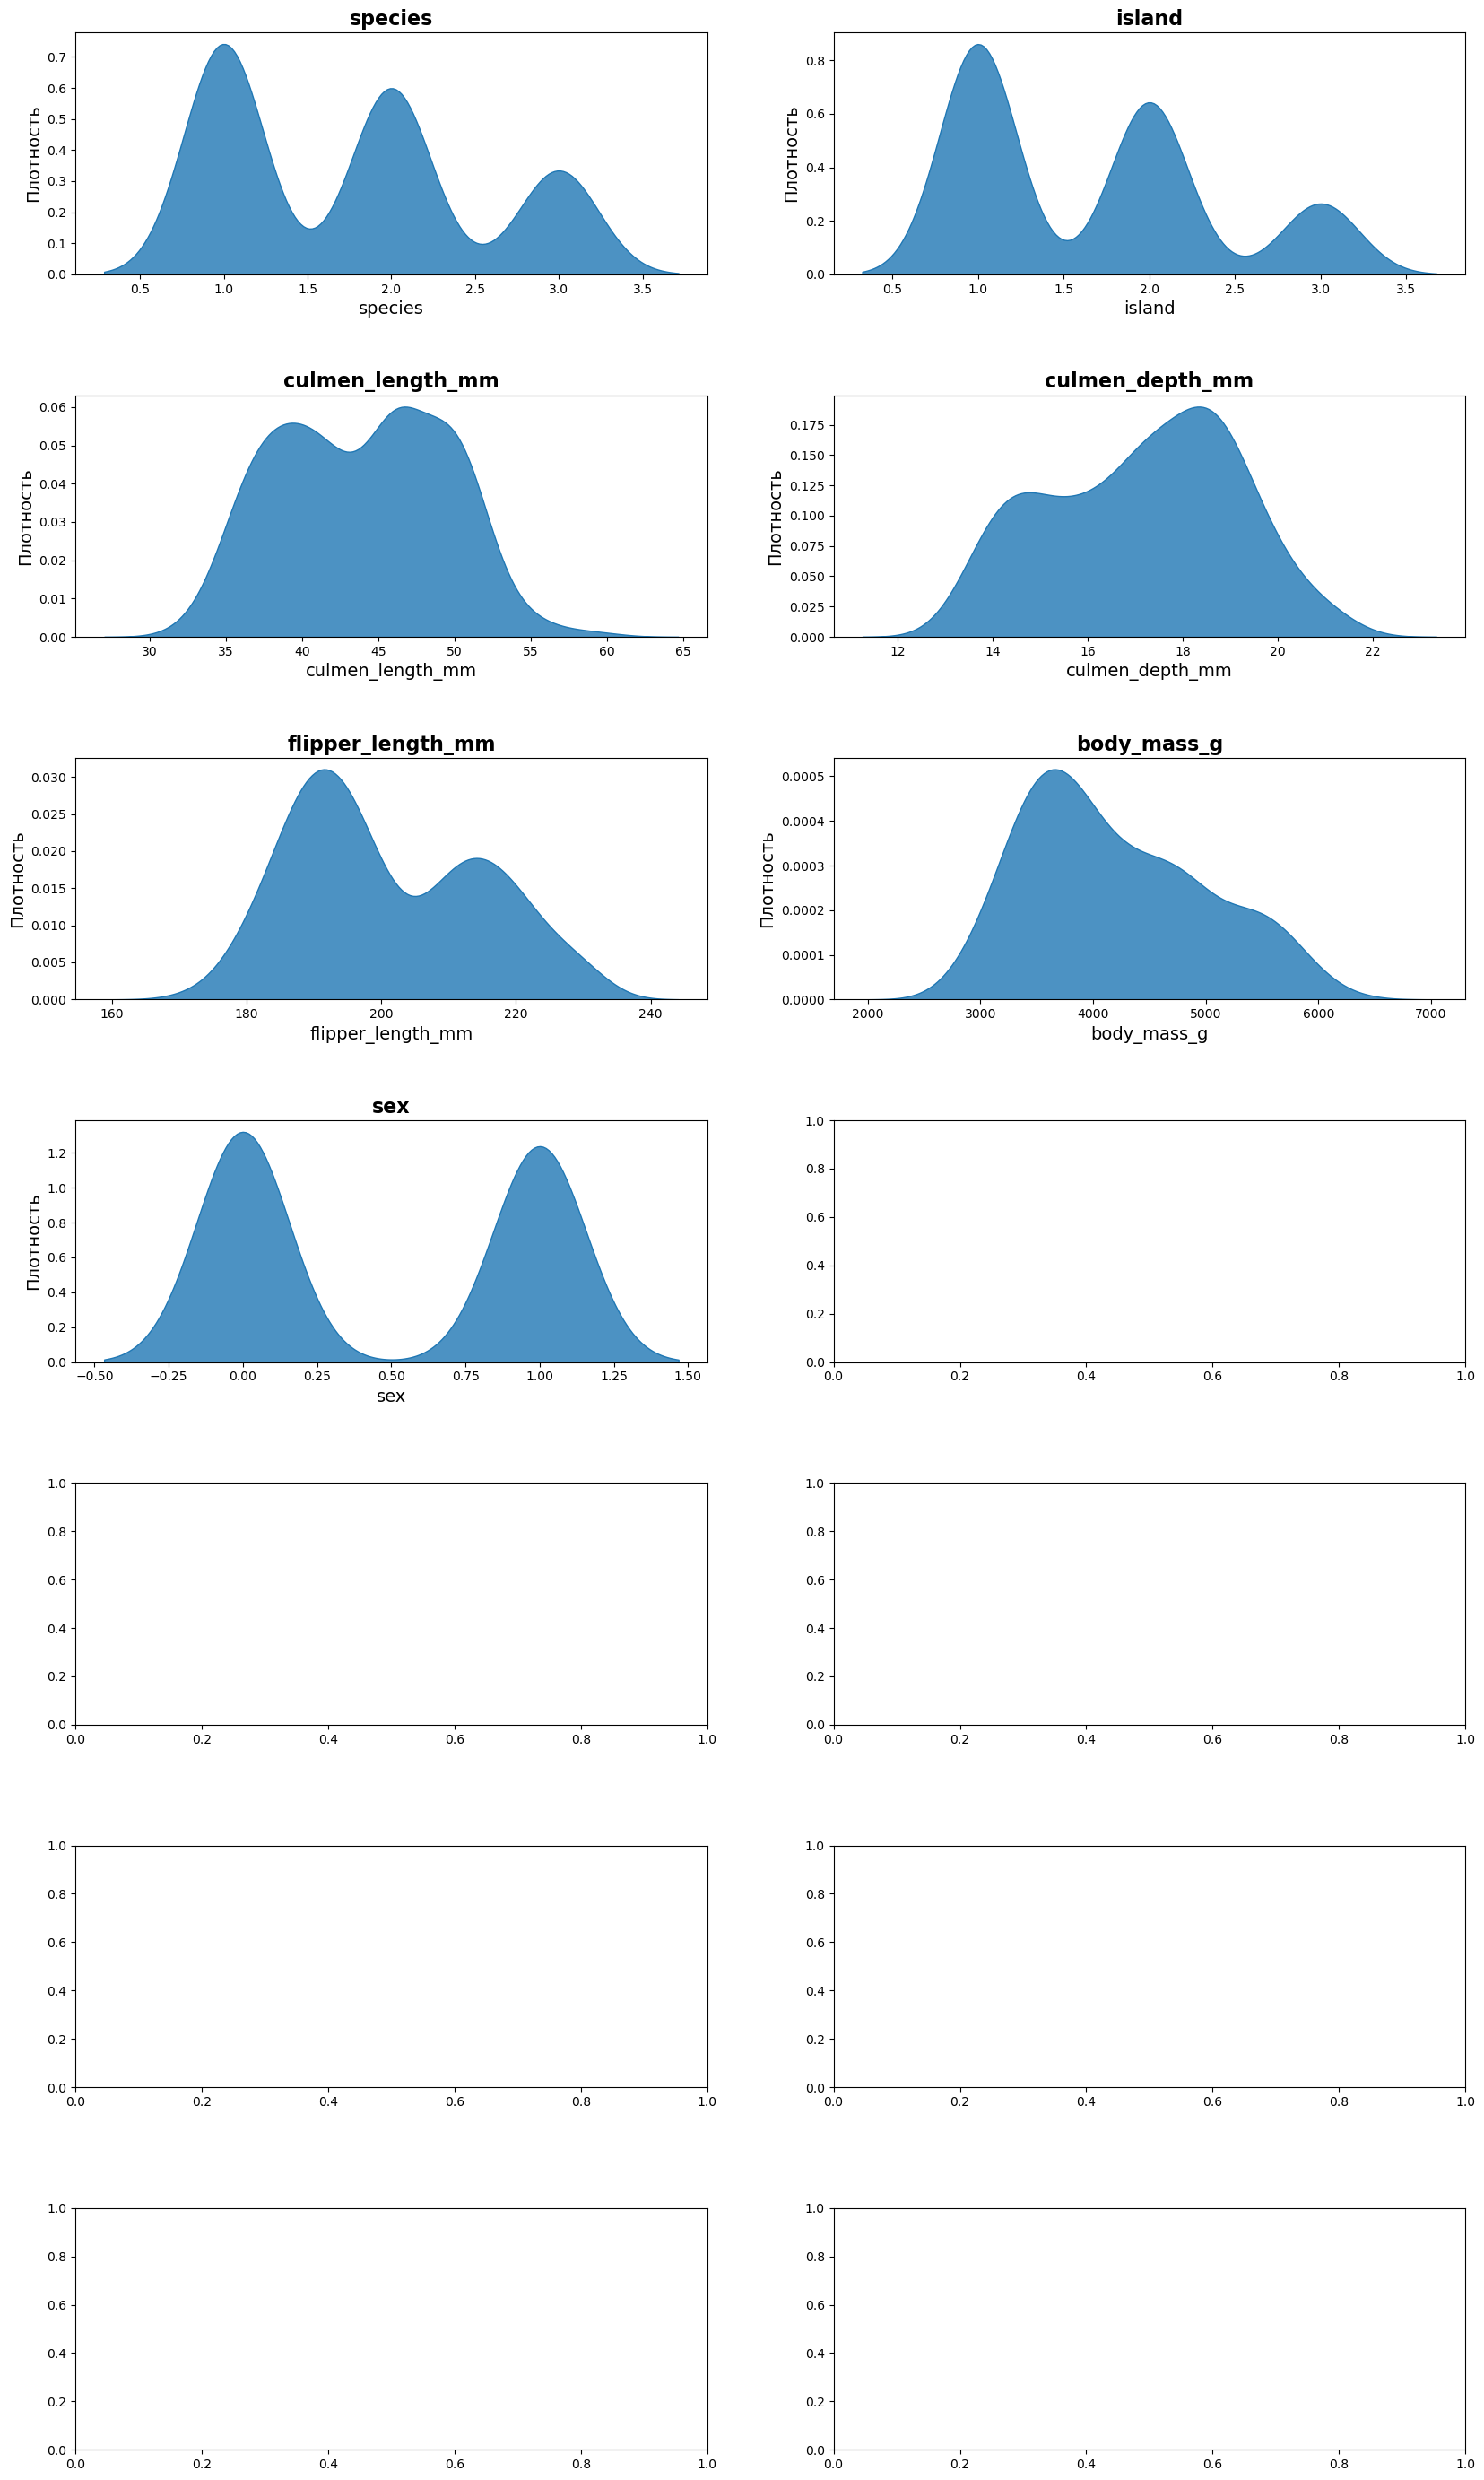

In [371]:
fig, axes = plt.subplots(7,2, figsize = (20,35))

# Расстояние между графиками
plt.subplots_adjust(hspace=0.5)

# Список значений признаков для цикла
columns = df.columns

# Строим распределения (kdeplot) для каждого признака
for i, column in enumerate(columns):
    ax = axes[i // 2, i % 2]
    sns.kdeplot(data = df,
                x = column,
                fill = True,
                alpha = 0.8,
                ax = ax)
    
    ax.set_title(column, fontweight = 'bold', fontsize = 16)
    ax.set_xlabel(column, fontsize = 14)
    ax.set_ylabel('Плотность', fontsize = 14)
    

plt.show()

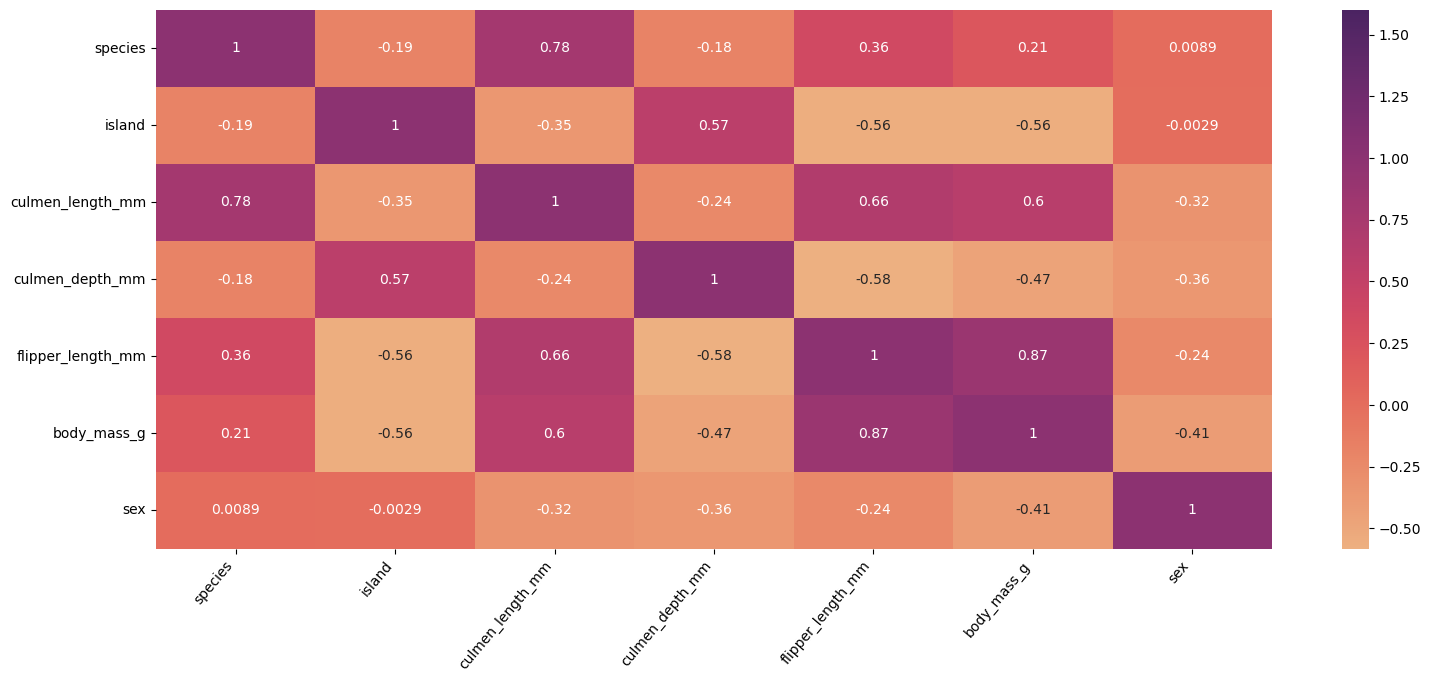

In [372]:
plt.figure(figsize = (18,7))
sns.heatmap(df.corr(),cmap = sns.color_palette("flare", as_cmap=True),annot = True,vmax = 1.6);
plt.xticks(rotation=50, ha='right');
plt.show()

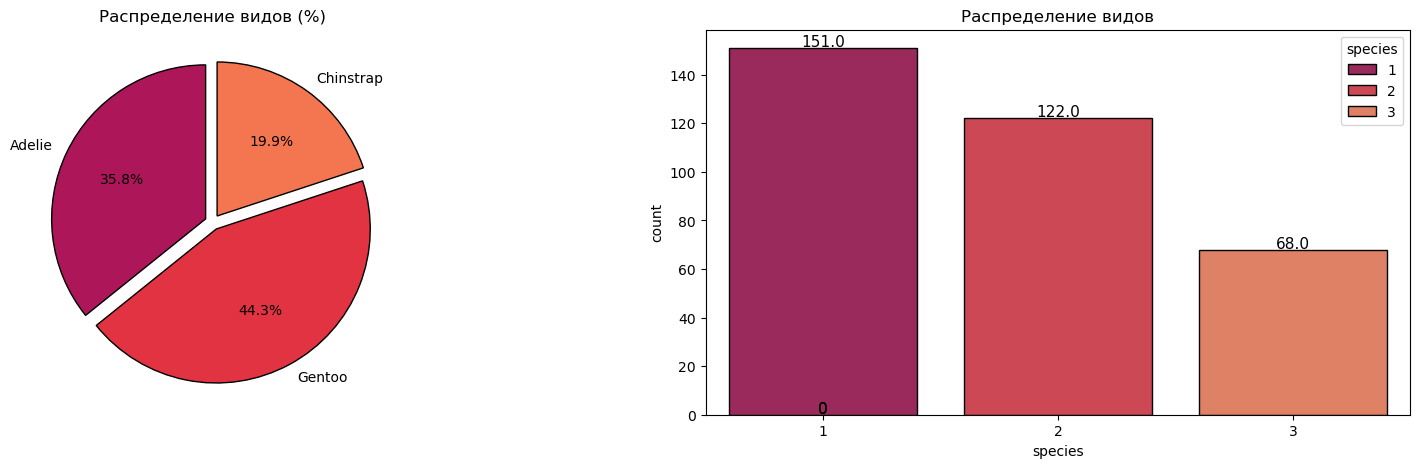

In [373]:
l = list(df['species'].value_counts())
sumLenn = sum(l)
proc = [l[1] / sumLenn * 100, l[0] / sumLenn * 100, l[2] / sumLenn * 100]
colors1 = sns.color_palette("rocket")[2:5]


fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (20, 5))
plt.subplot(1, 2, 1)
plt.pie(proc, labels = ['Adelie', 'Gentoo', 'Chinstrap'], 
        autopct = '%1.1f%%', 
        startangle = 90,
        explode = (0.05,0.05, 0.05), 
        colors = colors1, 
        wedgeprops = {'edgecolor' : 'black','antialiased' : True})
plt.title('Распределение видов (%)')

plt.subplot(1, 2, 2)
ax = sns.countplot(x = df['species'], 
                   hue = df['species'], 
                   palette = colors1, 
                   edgecolor = "black" )
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.7,\
            rect.get_height() , horizontalalignment='center', fontsize = 11)
plt.title('Распределение видов');
plt.show()

---

# Кластеризация

In [376]:
def showMetric(X, metrica):
    ch_score = calinski_harabasz_score(X, metrica)
    sil_score = silhouette_score(X, metrica)
    db_score = davies_bouldin_score(X, metrica)
    return [ch_score, sil_score, db_score]

In [377]:
X = df.drop('species', axis=1)
y = df['species']

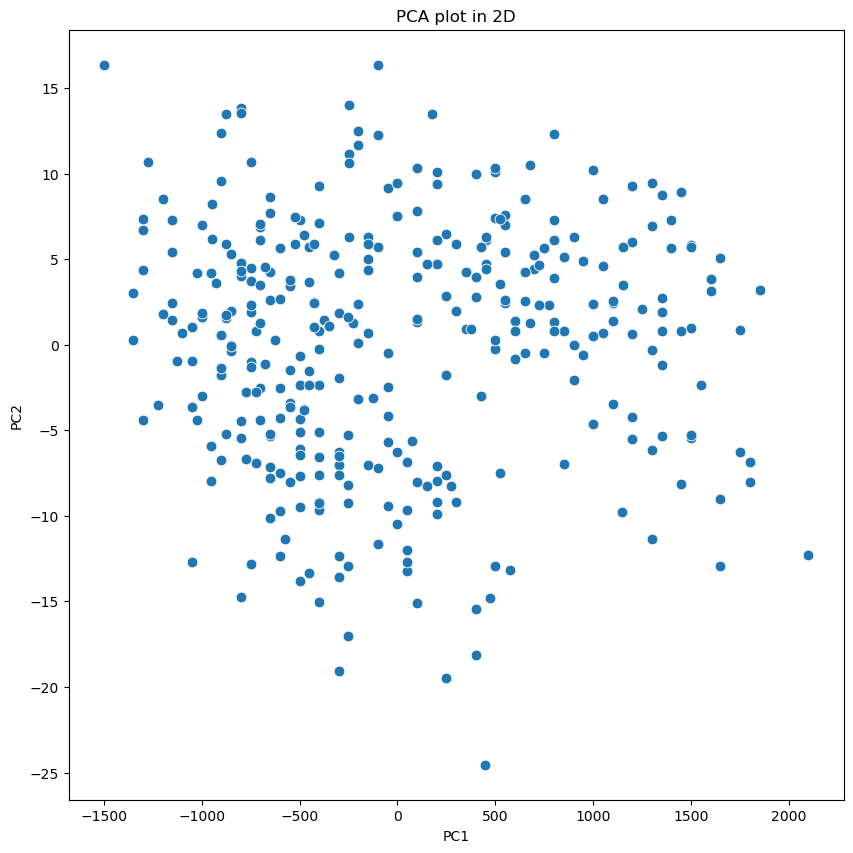

In [378]:
principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(df))
    
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                s=60)

plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');
plt.show()

In [379]:
def TSNEplot(pred=None):    
    tsne = TSNE(random_state=1)

    X_tsne = tsne.fit_transform(df)

    plt.figure(figsize=(12, 10))
    plt.scatter(X_tsne[:, 0], 
                X_tsne[:, 1], 
                c = pred, 
                edgecolor="none", 
                alpha=0.7, s=40,
        cmap=plt.cm.get_cmap("flare", 3))

    plt.colorbar()
    plt.title("t-SNE projection");
    plt.show()

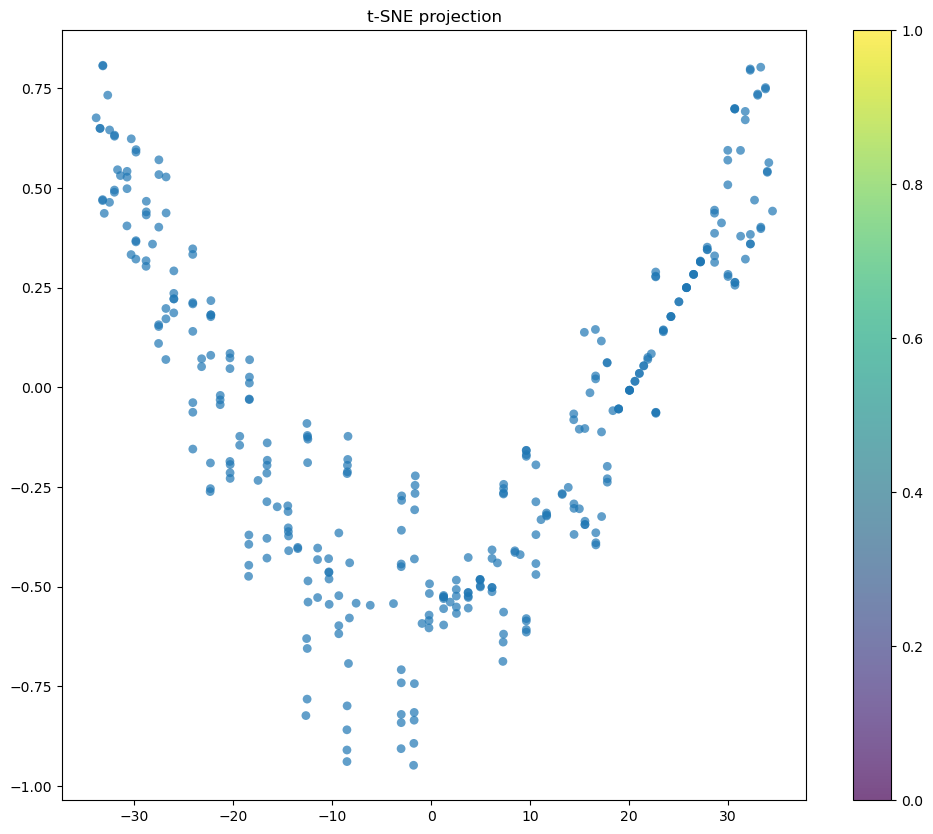

In [380]:
TSNEplot()

---

### KMeans

In [383]:
pca = PCA(n_components=2)

kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto').fit(X)
centroids_pca = pca.fit_transform(kmeans.cluster_centers_)
pred_k = kmeans.labels_

principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(X))
plt.show()

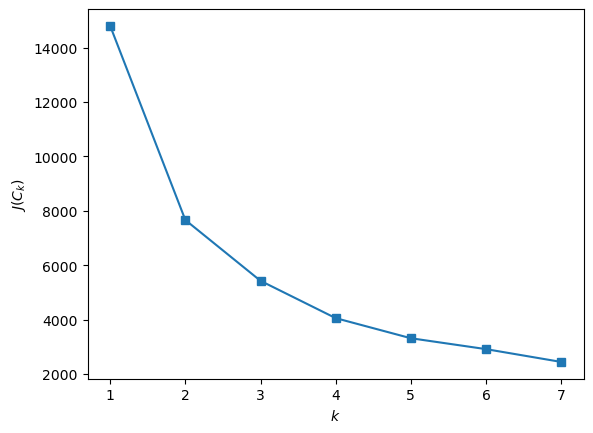

In [384]:
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init='auto').fit(X)
    inertia.append(np.sqrt(kmeans.inertia_))
    
plt.plot(range(1, 8), inertia, marker="s")
plt.xlabel("$k$")
plt.ylabel("$J(C_k)$");
plt.show()

In [385]:
pca = PCA(n_components=2)


kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto').fit(X)
centroids_pca = pca.fit_transform(kmeans.cluster_centers_)
pred_k = kmeans.labels_
df['cluster'] = kmeans.fit_predict(X)

principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(X))

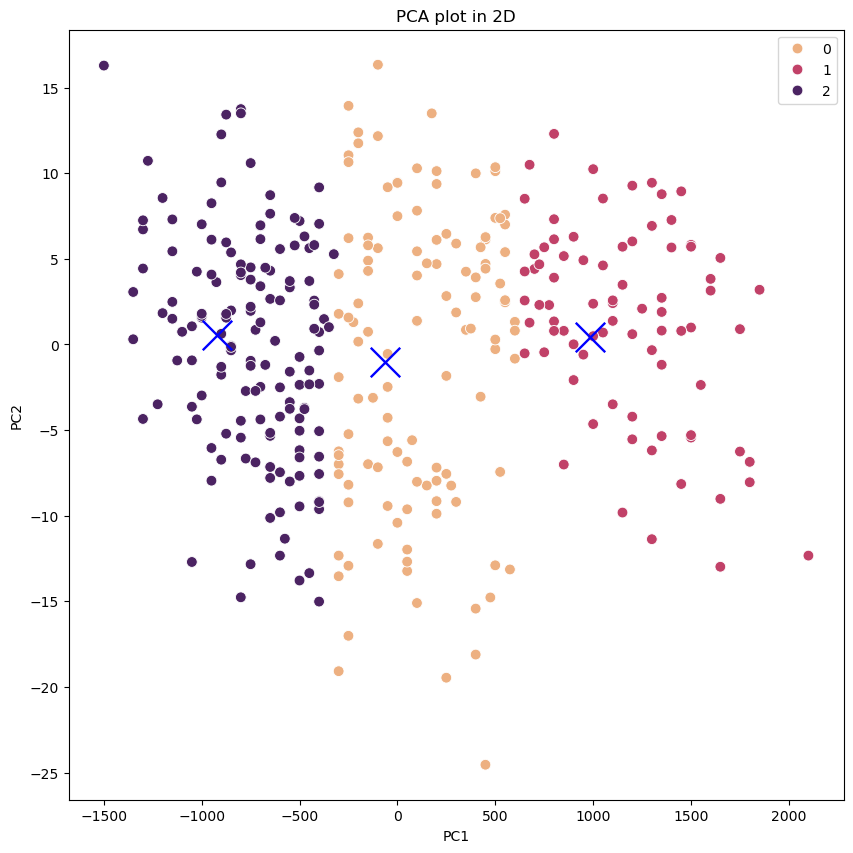

In [386]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_k, 
                palette="flare", 
                s=60)
sns.scatterplot(x = centroids_pca[:,0], 
                y =  centroids_pca[:,1],  
                marker="x", 
                s=450, 
                color = 'blue')
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');
plt.show()

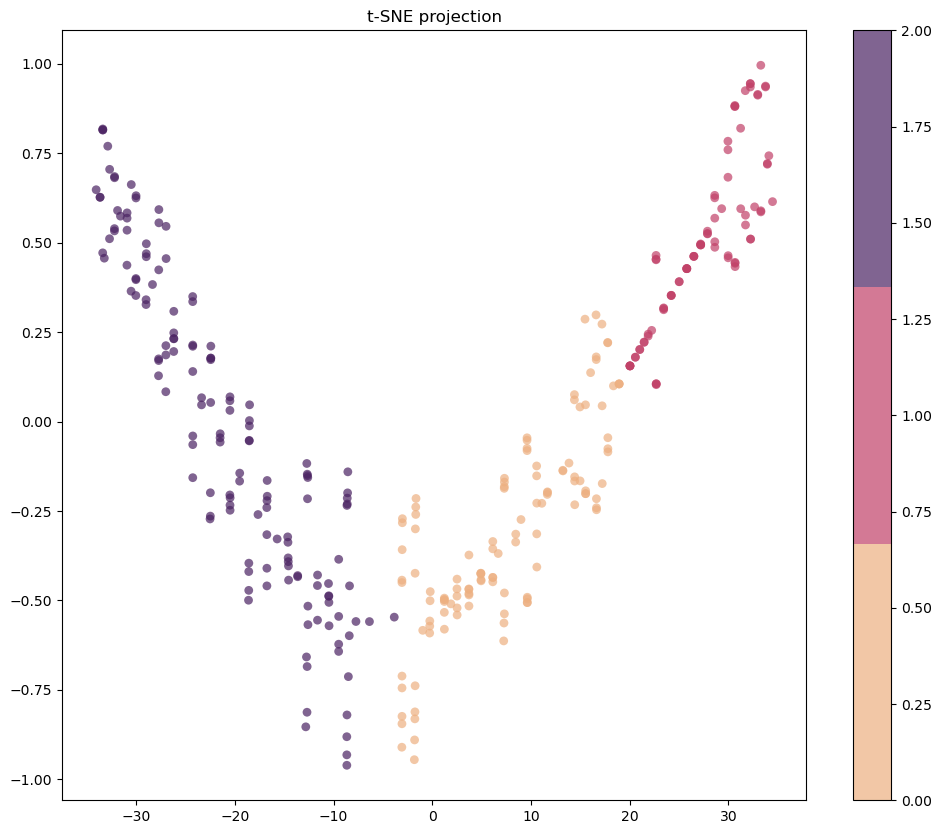

In [387]:
TSNEplot(pred_k)

In [388]:
print("K-Means метрики")
print("Calinski_harabasz_score: " + str(calinski_harabasz_score(X, kmeans.labels_)))
print("Silhouette_score: " + str(silhouette_score(X, kmeans.labels_)))
print("Davies_bouldin_score: " + str(davies_bouldin_score(X, kmeans.labels_)))

K-Means метрики
Calinski_harabasz_score: 1088.8699626810678
Silhouette_score: 0.5598972371838294
Davies_bouldin_score: 0.5374061686156574


---

### Algomerative Clustering

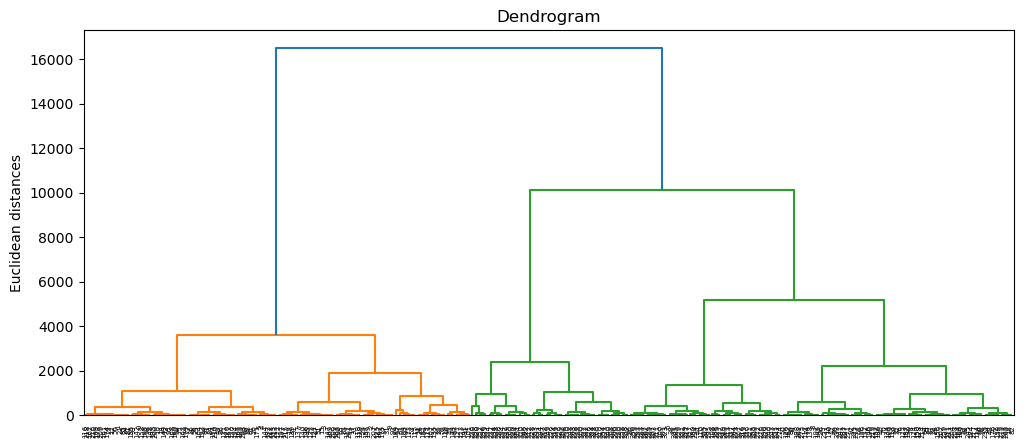

In [391]:
import scipy.cluster.hierarchy as sch
from matplotlib import pyplot
pyplot.figure(figsize=(12, 5))
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.ylabel('Euclidean distances')
plt.show()

In [392]:
clustering_ward = AgglomerativeClustering(3).fit(X)
pred_ward = clustering_ward.labels_

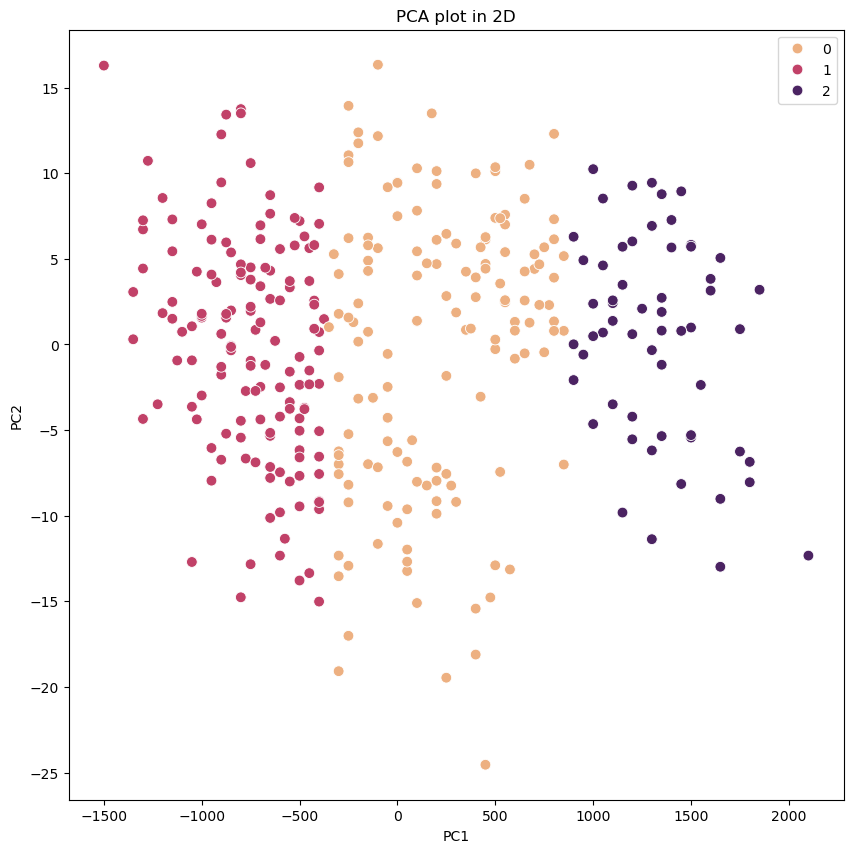

In [393]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_ward, 
                palette="flare", 
                s=60)
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');
plt.show()

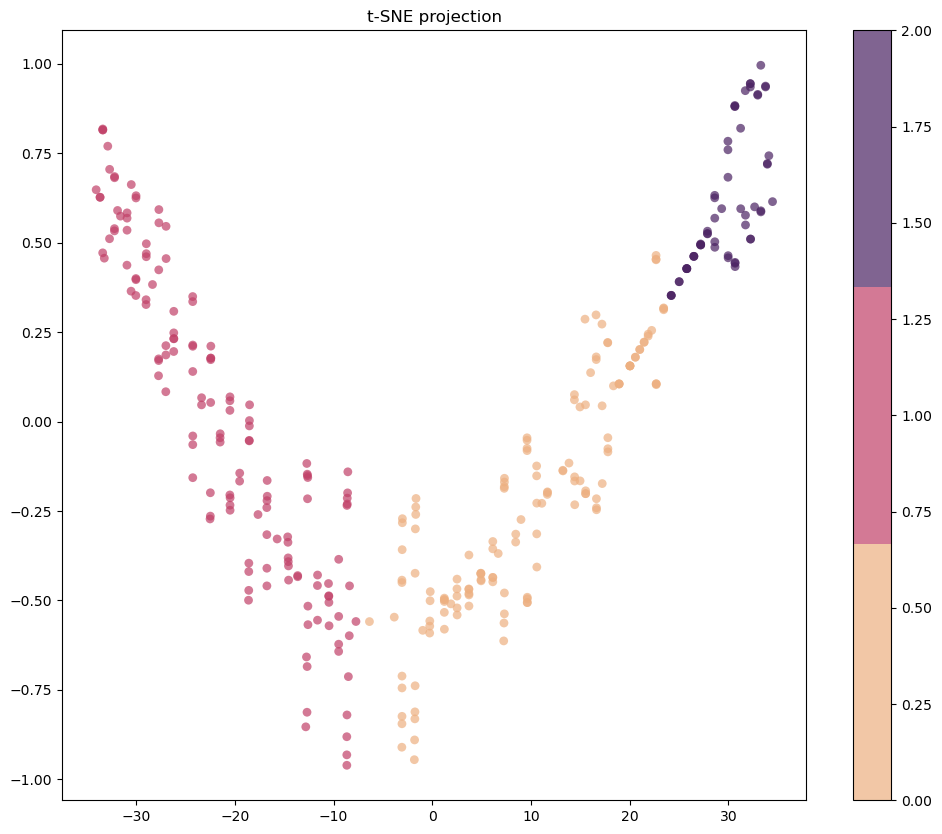

In [394]:
TSNEplot(pred_ward)
plt.show()

In [395]:
print("AgglomerativeClustering метрики")
print("Calinski_harabasz_score: " + str(calinski_harabasz_score(X, clustering_ward.labels_)))
print("Silhouette_score: " + str(silhouette_score(X, clustering_ward.labels_)))
print("Davies_bouldin_score: " + str(davies_bouldin_score(X, clustering_ward.labels_)))

AgglomerativeClustering метрики
Calinski_harabasz_score: 996.5298810945916
Silhouette_score: 0.5505940914005499
Davies_bouldin_score: 0.5240348053739868


### Spectral

In [397]:
clustering_sp = SpectralClustering(3).fit(X)
pred_sp = clustering_sp.labels_

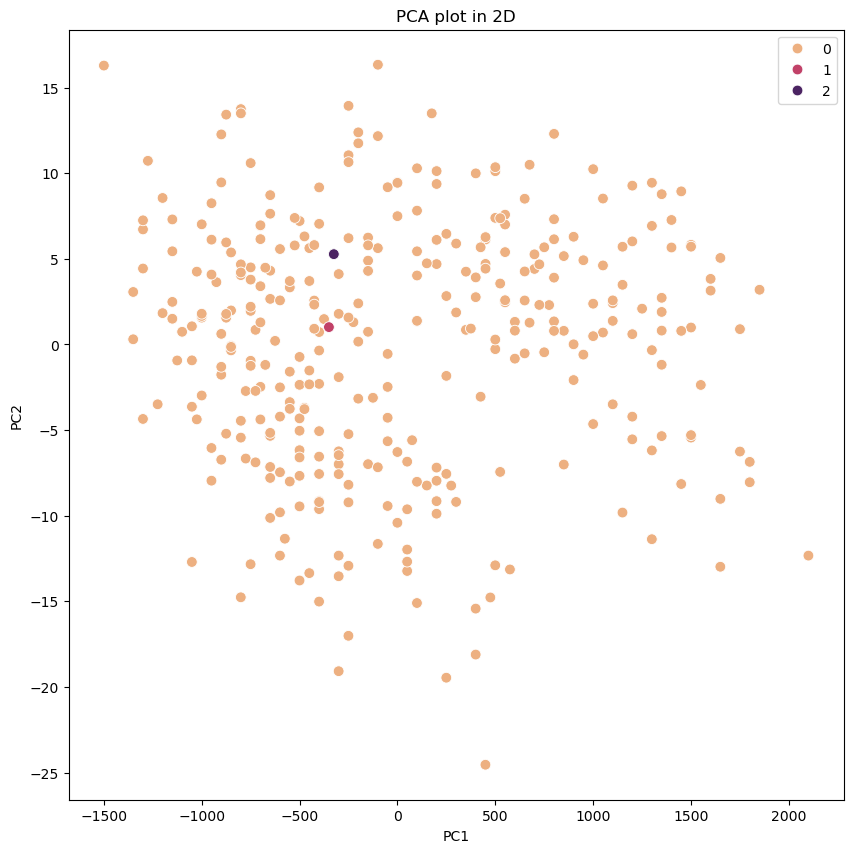

In [398]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_sp, 
                palette="flare", 
                s=60)
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');
plt.show()

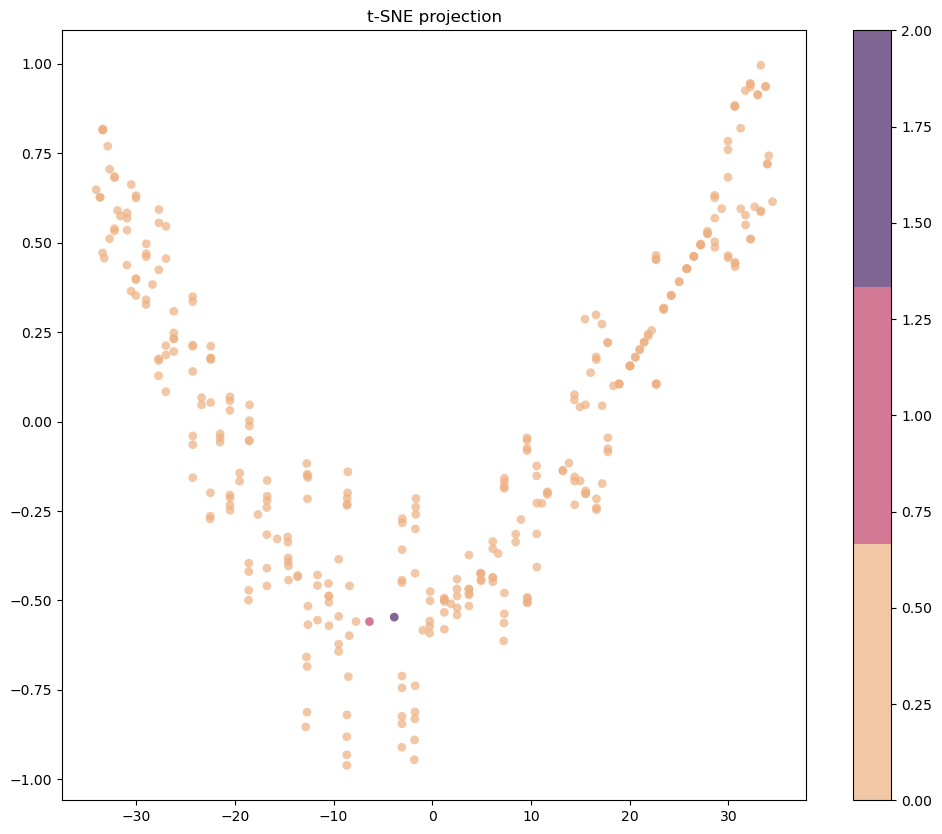

In [399]:
TSNEplot(pred_sp)
plt.show()

In [400]:
print("SpectralClustering метрики")
print("Calinski_harabasz_score: " + str(calinski_harabasz_score(X, clustering_sp.labels_)))
print("Silhouette_score: " + str(silhouette_score(X, clustering_sp.labels_)))
print("Davies_bouldin_score: " + str(davies_bouldin_score(X, clustering_sp.labels_)))

SpectralClustering метрики
Calinski_harabasz_score: 0.17713606509228558
Silhouette_score: -0.35142906810230495
Davies_bouldin_score: 2.027663081305834


Вывод. Спектральная кластеризация не подошла. все объекты были определены в одну группу

---

### Сравнение моделей

In [404]:
rs_k = rand_score(kmeans.labels_, y) 
rs_ward = rand_score(pred_ward, y)
rs_sp = rand_score(pred_sp, y)

print('\nK-Means')
print('_'*45 + '\n')
print(" rand_score = {} \n\n {} из 337 предсказано верно \n\n\n\n".format(rs_k, rs_k * 178))


print('Agglomerative Clustering')
print('_'*45 + '\n')
print(" rand_score = {} \n\n {} из 337 предсказано верно \n\n\n\n".format(rs_ward, rs_ward * 178))


print('Spectral Clustering')
print('_'*45 + '\n')
print(" rand_score = {} \n\n {} из 337 предсказано верно \n".format(rs_sp, rs_sp * 178))


K-Means
_____________________________________________

 rand_score = 0.6827669484215974 

 121.53251681904433 из 337 предсказано верно 




Agglomerative Clustering
_____________________________________________

 rand_score = 0.6460238054165948 

 114.99223736415387 из 337 предсказано верно 




Spectral Clustering
_____________________________________________

 rand_score = 0.3662066586165258 

 65.1847852337416 из 337 предсказано верно 



# Вывод:

По результату K-Means показал лучшее качество кластеризации по сравнению с Agglomerative Clustering и Spectral Clustering.
Spectral Clustering продемонстрировал худшие результаты так как не подходит для таких типов кластеризации.

## Обучение Классификаторов

In [503]:
X = df.drop(columns=['cluster'])

In [504]:
y = df['cluster']

In [505]:
# Разделяем выборку на обучающую и тестовую 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

---

### Классификатор KMeans

In [508]:
from sklearn.neighbors import KNeighborsClassifier

In [509]:
%%time
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

CPU times: total: 0 ns
Wall time: 8.24 ms


KNeighborsClassifier()

In [510]:
# Предугадываем тренировочную выборку 
knn.predict(X_test)

array([1, 2, 0, 0, 0, 1, 0, 2, 1, 2, 0, 1, 0, 1, 2, 0, 2, 2, 2, 2, 0, 2,
       1, 2, 0, 0, 0, 2, 2, 1, 2, 2, 2, 1, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0,
       2, 2, 0, 0, 2, 2, 0, 2, 1, 0, 2, 0, 2, 0, 1, 2, 0, 1, 1, 0, 2, 0,
       2, 0, 0, 0, 2, 2, 1, 0, 0, 2, 0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 0,
       2, 1, 0, 1, 0, 1, 2, 2, 2, 2, 2, 0, 0, 2, 0, 2, 1, 0, 2, 1, 1, 2,
       2, 2, 0])

In [511]:
# измерение производительности
y_train_predict = knn.predict(X_train) 
y_test_predict = knn.predict(X_test)

print('train accuracy: ', accuracy_score(y_train, y_train_predict, normalize=True))
print('test accuracy: ', accuracy_score(y_test, y_test_predict, normalize=True))
knn_accuracy = accuracy_score(y_test, y_test_predict, normalize=True)

train accuracy:  0.9956140350877193
test accuracy:  1.0


In [512]:
print(classification_report( y_test, y_test_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        49

    accuracy                           1.00       113
   macro avg       1.00      1.00      1.00       113
weighted avg       1.00      1.00      1.00       113



---

### Гаусовский классификатор

In [515]:
from sklearn.naive_bayes import GaussianNB

In [516]:
%%time

gnb = GaussianNB()
gnb.fit(X, y)

CPU times: total: 0 ns
Wall time: 0 ns


GaussianNB()

In [517]:
# измерение производительности
gnb_y_train_predict = gnb.predict(X_train)
gnb_y_test_predict = gnb.predict(X_test)

print('train accuracy: ', accuracy_score(y_train, gnb_y_train_predict, normalize=True))
print('test accuracy: ', accuracy_score(y_test, gnb_y_test_predict, normalize=True))
gnb_accuracy = accuracy_score(y_test, gnb_y_test_predict)

train accuracy:  0.8552631578947368
test accuracy:  0.8407079646017699


In [518]:
print(classification_report( y_test, y_test_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        49

    accuracy                           1.00       113
   macro avg       1.00      1.00      1.00       113
weighted avg       1.00      1.00      1.00       113



---

### Random Forest Классификатор

In [521]:
from sklearn.ensemble import RandomForestClassifier

In [522]:
%%time
rfc  = RandomForestClassifier(criterion = 'gini',
                                    n_estimators = 100,
                                    max_depth = 9,
                                    random_state = 42,
                                    n_jobs = -1)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

CPU times: total: 297 ms
Wall time: 285 ms


In [523]:
rfc_y_train_predict = rfc.predict(X_train)
rfc_y_test_predict = rfc.predict(X_test)

print('train accuracy: ', accuracy_score(y_train, rfc_y_train_predict, normalize=True))
print('test accuracy: ', accuracy_score(y_test, rfc_y_test_predict, normalize=True))
rfc_accuracy = accuracy_score(y_test, rfc_y_test_predict)

train accuracy:  1.0
test accuracy:  1.0


In [524]:
print(classification_report( y_test, y_test_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        49

    accuracy                           1.00       113
   macro avg       1.00      1.00      1.00       113
weighted avg       1.00      1.00      1.00       113



### Метритки классификации

In [526]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [527]:
classifiers =["KNeighborsClassifier", "Gaussian Naive Bayes", "Random Forest Classifier"]

log_cols = ["Classifier", "Accuracy"]
log = pd.DataFrame(columns=log_cols)

log["Classifier"] = classifiers
log["Accuracy"] = [knn_accuracy, gnb_accuracy, rfc_accuracy]

In [528]:
log

,Classifier,Accuracy
0,KNeighborsClassifier,1.000000
1,Gaussian Naive Bayes,0.840708
2,Random Forest Classifier,1.000000


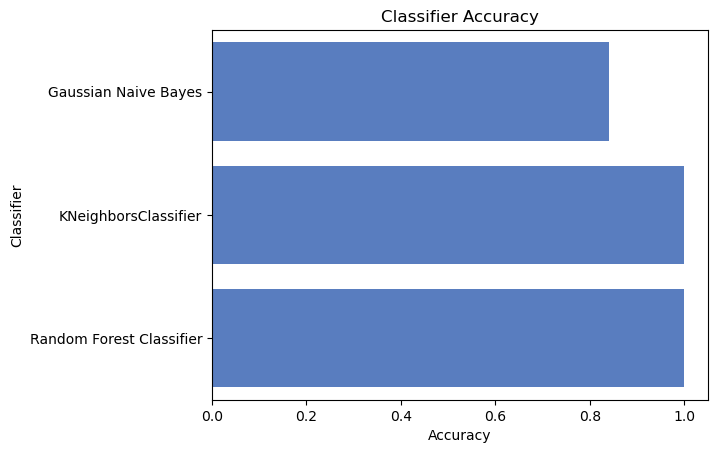

In [529]:
plt.xlabel('Accuracy')
plt.title('Classifier Accuracy')

sns.set_color_codes("muted")
sns.barplot(x='Accuracy', y='Classifier', data=log.sort_values(by='Accuracy'), color="b");
plt.show()

## Вывод

Лучше всего себя показал Random Forest Classifier, с не большим отрывом от Gaussian Naive Bayes, очевидно что много данных довольно хорошо корилируют между самбой и в целом для такого рода классификации Random Forest Classifier лучше всего себя покажет.